In [36]:
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = 12, 10
from itertools import product

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats

In [37]:
def invboxcox(y, lmbda):
    if lmbda == 0:
        return np.exp(y)
    else:
        return np.exp(np.log(lmbda * y + 1) / lmbda)

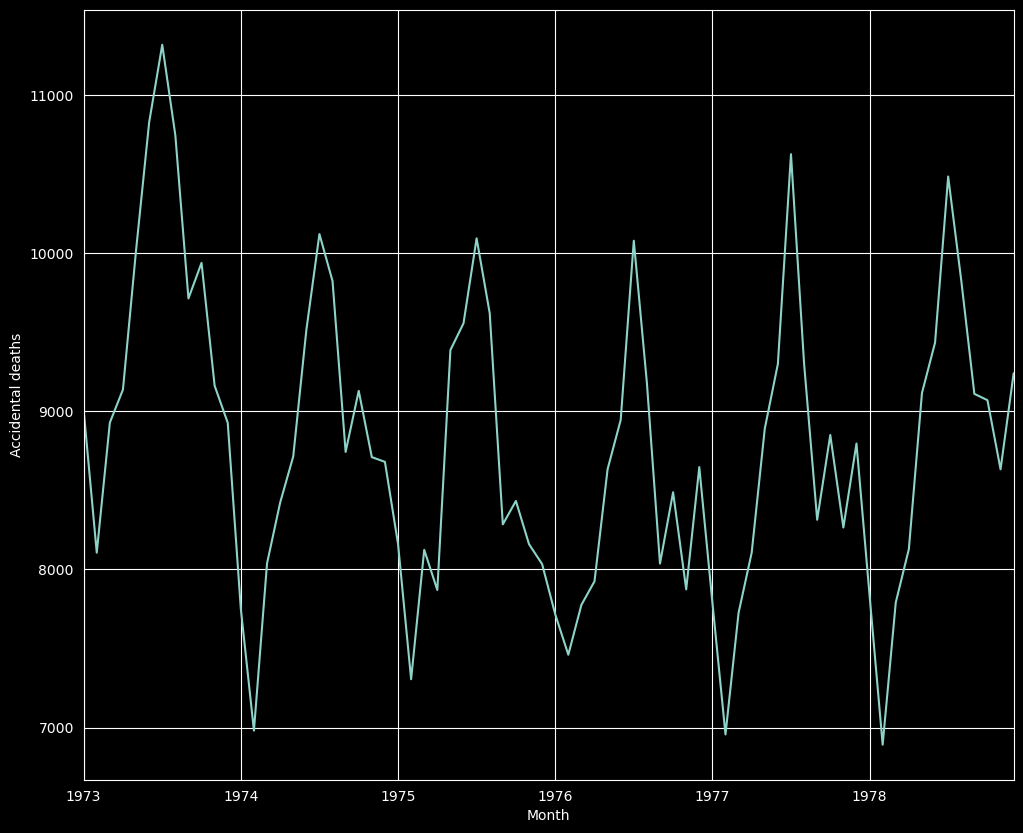

In [38]:
df = pd.read_csv(
    '../data/accidental-deaths-in-usa-monthly.csv',
    index_col=['Month'],
    parse_dates=['Month']
)
df.rename(
    columns={"Accidental deaths in USA: monthly, 1973 ? 1978": "num_deaths"},
    inplace=True
)

df['num_deaths'].plot()
plt.ylabel('Accidental deaths');

Критерий Дики-Фуллера: p=0.102481


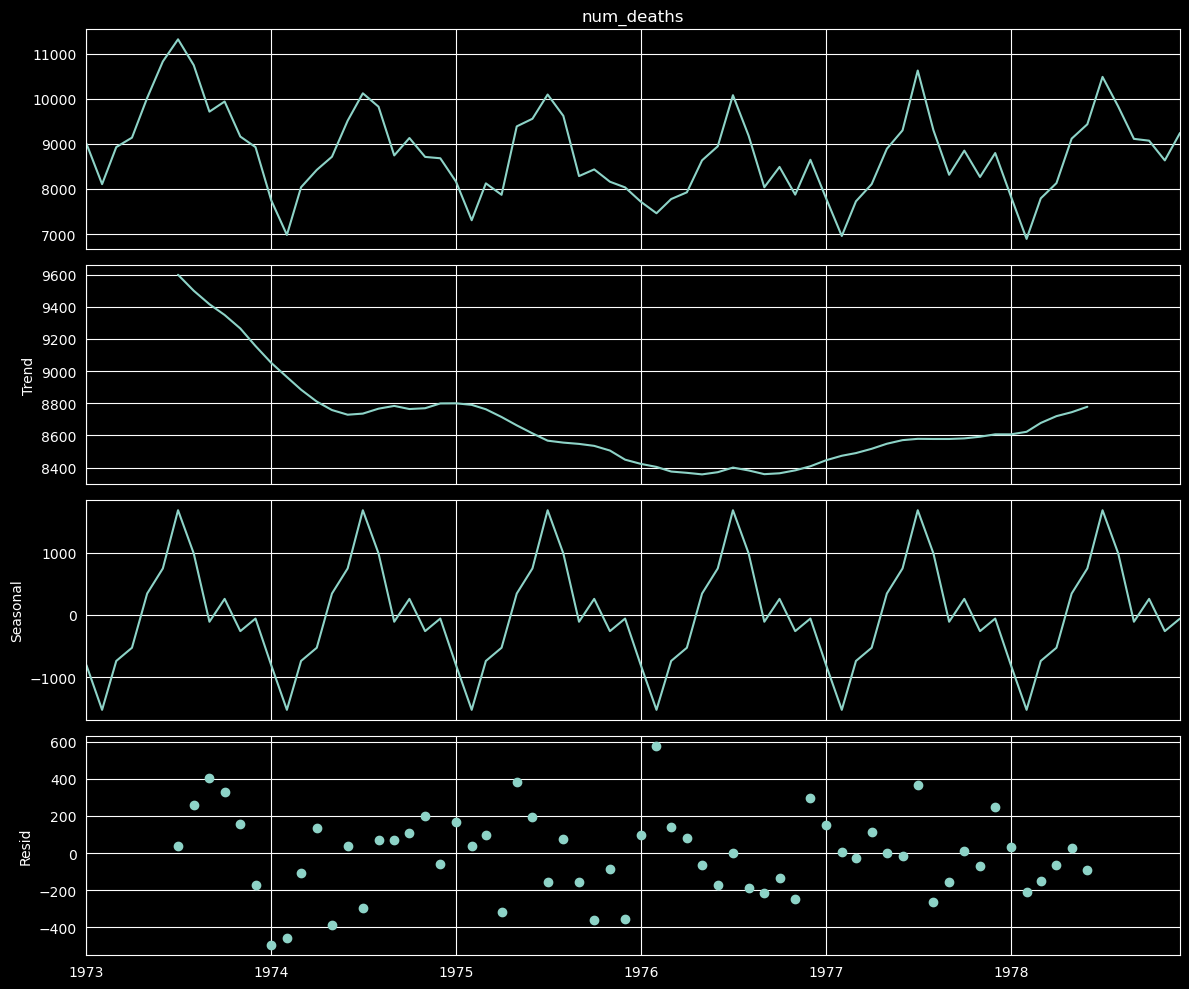

In [39]:
sm.tsa.seasonal_decompose(df['num_deaths']).plot()
print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(df["num_deaths"])[1])

Критерий Дики-Фуллера: p=0.014650


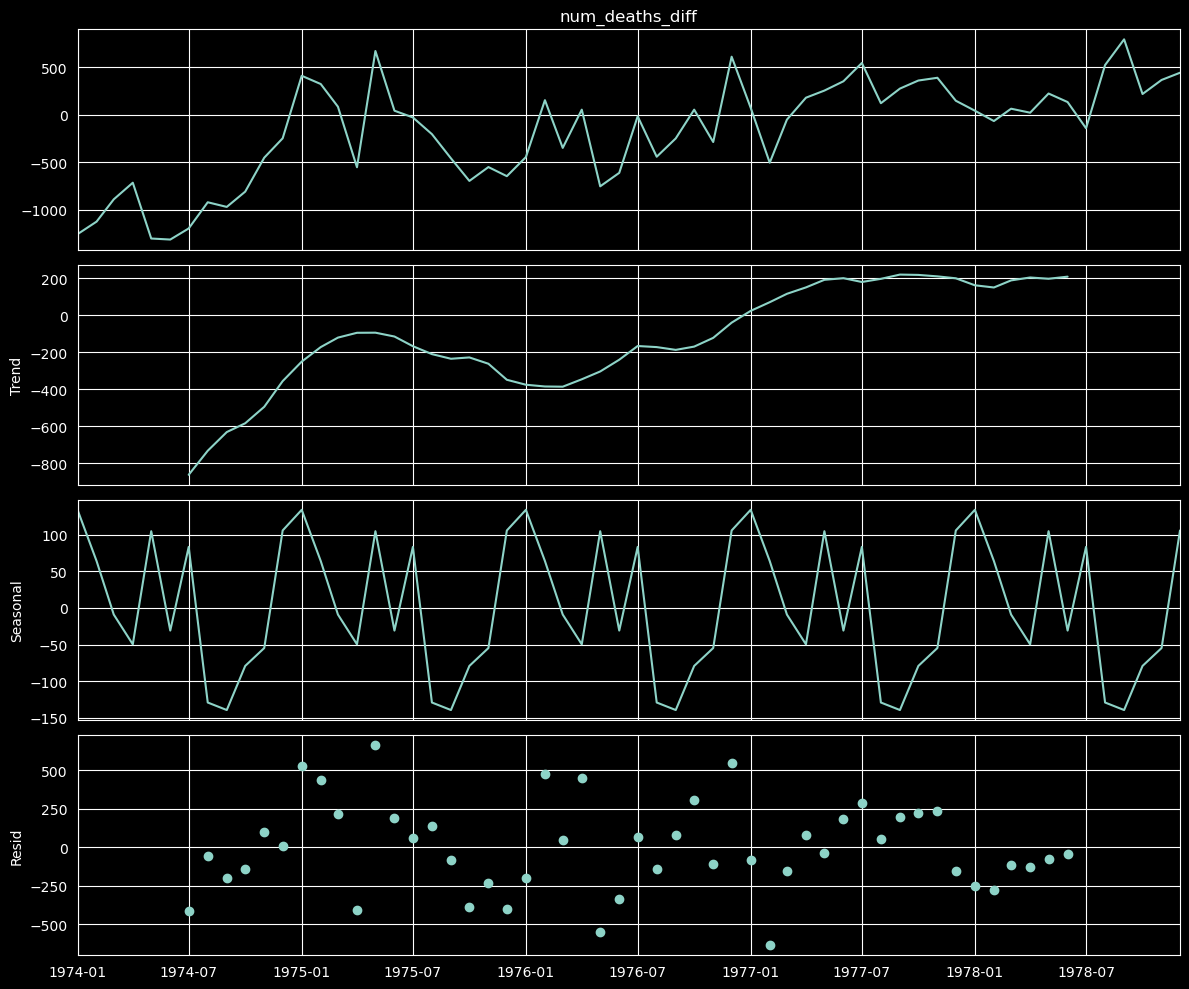

In [40]:
df['num_deaths_diff'] = df['num_deaths'] - df['num_deaths'].shift(12)
sm.tsa.seasonal_decompose(df['num_deaths_diff'][12:]).plot()
print("Критерий Дики-Фуллера: p=%f"% sm.tsa.stattools.adfuller(df["num_deaths_diff"][12:])[1])

Критерий Дики-Фуллера: p=0.000000


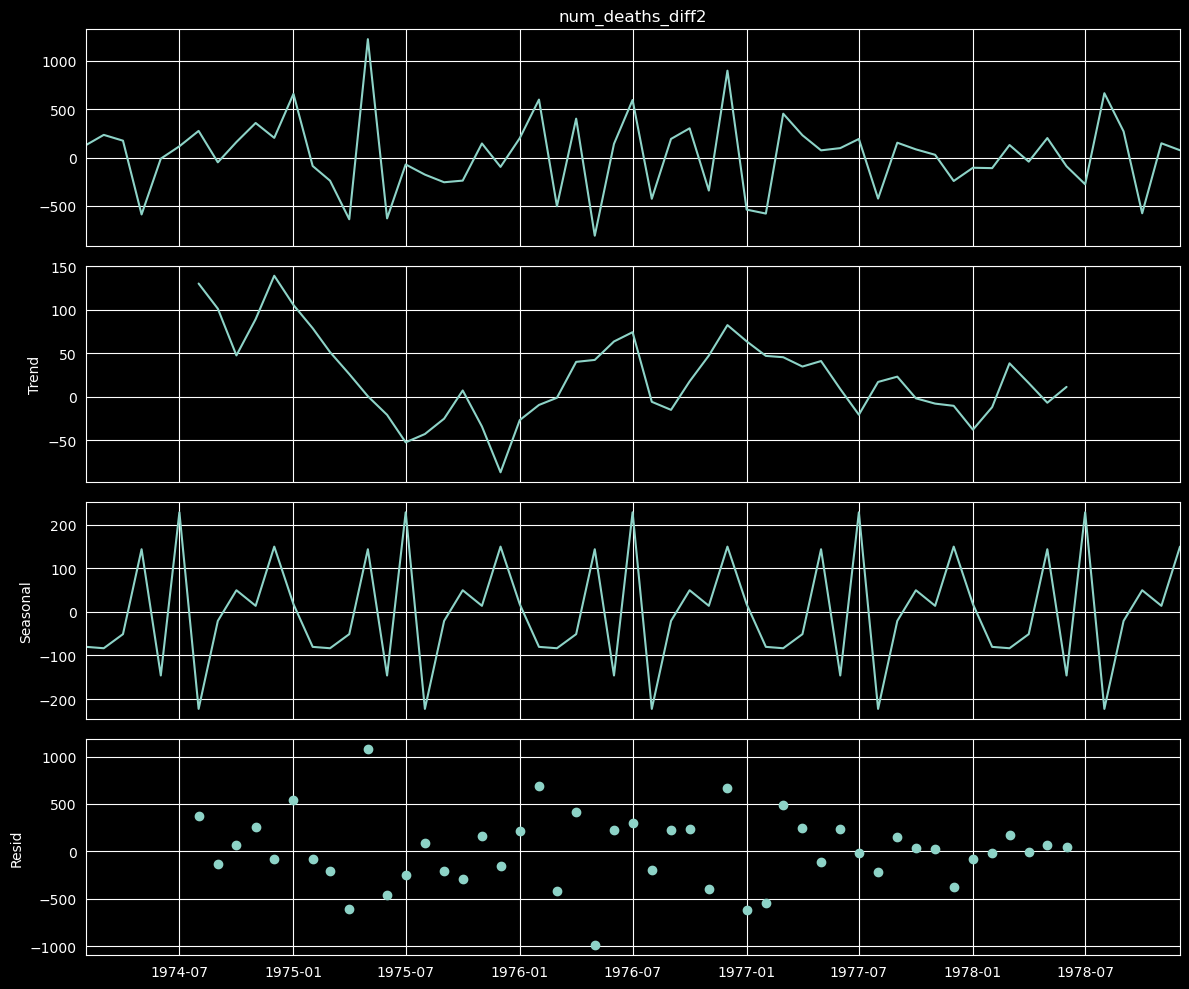

In [41]:
df['num_deaths_diff2'] = df['num_deaths_diff'] - df['num_deaths_diff'].shift(1)
sm.tsa.seasonal_decompose(df['num_deaths_diff2'][13:]).plot()
print("Критерий Дики-Фуллера: p=%f"% sm.tsa.stattools.adfuller(df["num_deaths_diff2"][13:])[1])

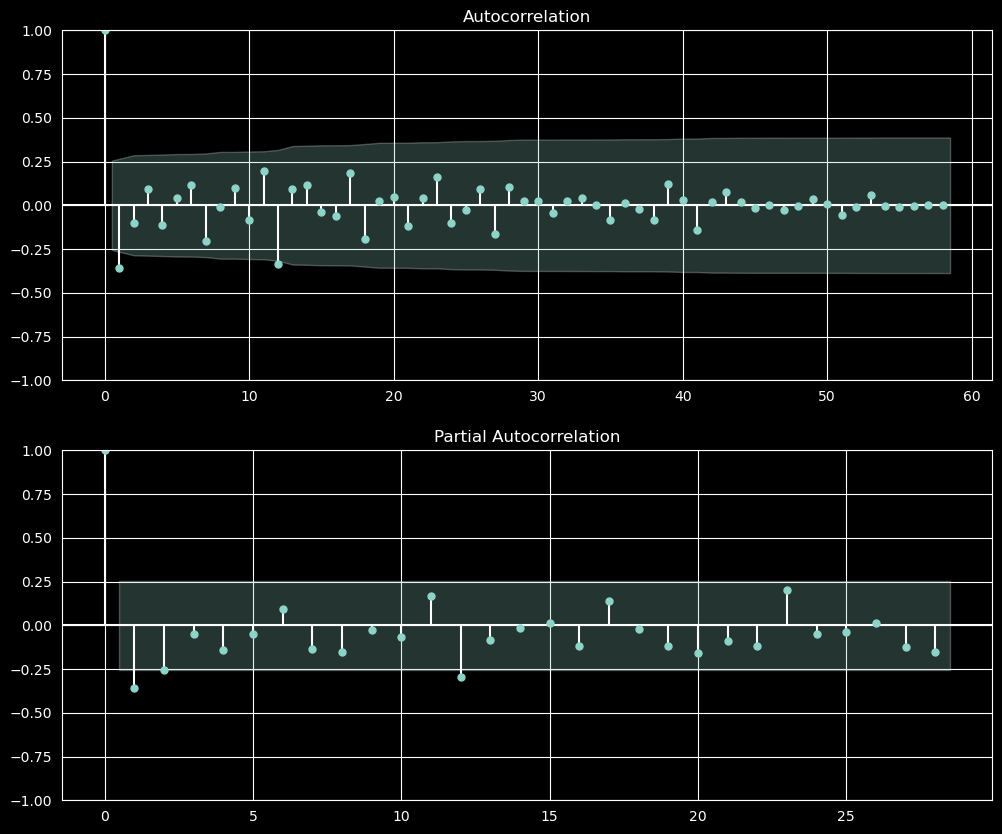

In [42]:
ax = plt.subplot(211)
sm.graphics.tsa.plot_acf(
    df['num_deaths_diff2'][13:].values.squeeze(),
    lags=58,
    ax=ax
)
ax = plt.subplot(212)
sm.graphics.tsa.plot_pacf(
    df['num_deaths_diff2'][13:].values.squeeze(),
    lags=28,
    ax=ax
);

In [43]:
ps = range(0, 3)
d = 1
qs = range(0, 1)
Ps = range(0, 3)
D = 1
Qs = range(0, 3)

In [44]:
parameters = product(ps, qs, Ps, Qs)
parameters_list = list(parameters)
len(parameters_list)

27

In [45]:
%%time
results = []
best_aic = float('inf')

for param in parameters_list:
    # try except нужен, потому что на некоторых наборах параметров модель не обучается
    try:
        model = sm.tsa.statespace.SARIMAX(
            df["num_deaths"],
            order=(param[0], d, param[1]),
            seasonal_order=(param[2], D, param[3], 12),
        ).fit(disp=-1)

    # выводим параметры, на которых модель не обучается и переходим к следующему набору
    except ValueError:
        print("wrong parameters:", param)
        continue
    aic = model.aic

    # сохраняем лучшую модель, aic, параметры
    if aic < best_aic:
        best_model = model
        best_aic = aic
        best_param = param
    results.append([param, model.aic])

warnings.filterwarnings("default")

CPU times: user 8.74 s, sys: 1.54 s, total: 10.3 s
Wall time: 8.35 s


In [46]:
result_table = pd.DataFrame(results)
result_table.columns = ['parameters', 'aic']
print(result_table.sort_values(by='aic', ascending=True).head())

      parameters         aic
19  (2, 0, 0, 1)  854.647098
10  (1, 0, 0, 1)  855.458079
24  (2, 0, 2, 0)  856.494101
20  (2, 0, 0, 2)  856.603171
22  (2, 0, 1, 1)  856.614483


In [47]:
print(best_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                           num_deaths   No. Observations:                   72
Model:             SARIMAX(2, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -423.324
Date:                              Sat, 20 Jun 2026   AIC                            854.647
Time:                                      14:38:23   BIC                            862.957
Sample:                                  01-01-1973   HQIC                           857.891
                                       - 12-01-1978                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3724      0.112     -3.329      0.001      -0.592      -0.153
ar.L2         -0.19

Критерий Стьюдента: p=0.274373
Критерий Дики-Фуллера: p=0.000000


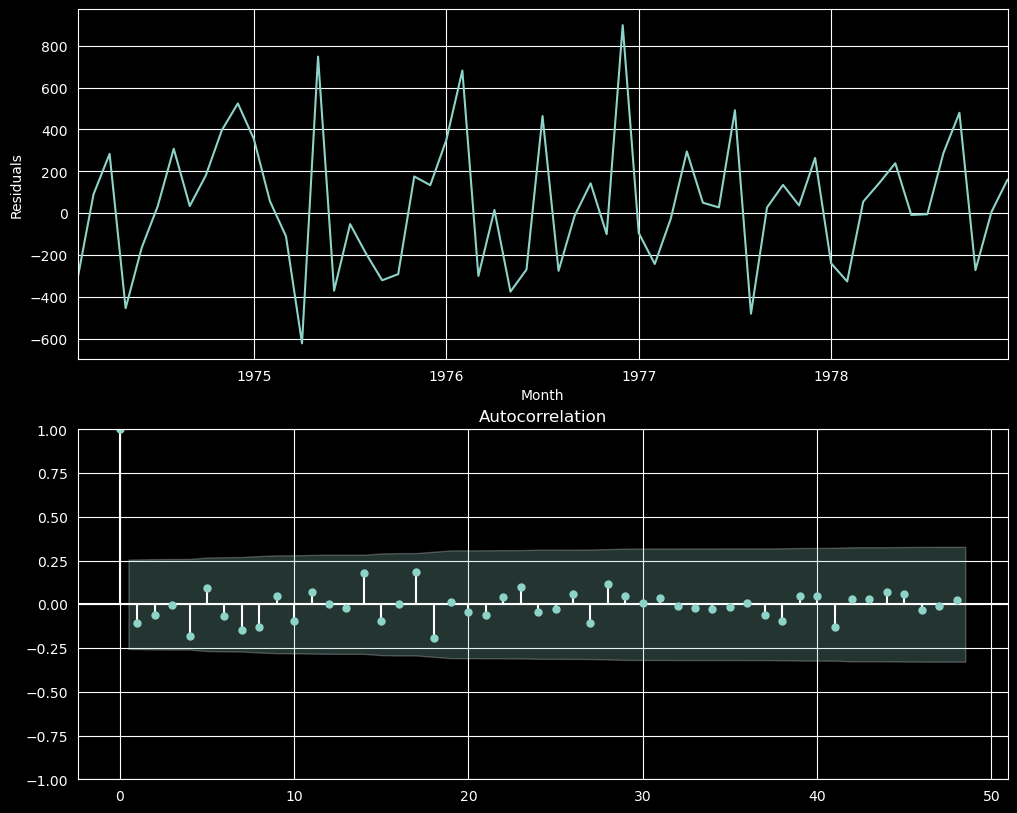

In [48]:
plt.subplot(211)
best_model.resid[13:].plot()
plt.ylabel(u'Residuals')

ax = plt.subplot(212)
sm.graphics.tsa.plot_acf(best_model.resid[13:].values.squeeze(), lags=48, ax=ax)

print("Критерий Стьюдента: p=%f" % stats.ttest_1samp(best_model.resid[13:], 0)[1])
print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(best_model.resid[13:])[1])

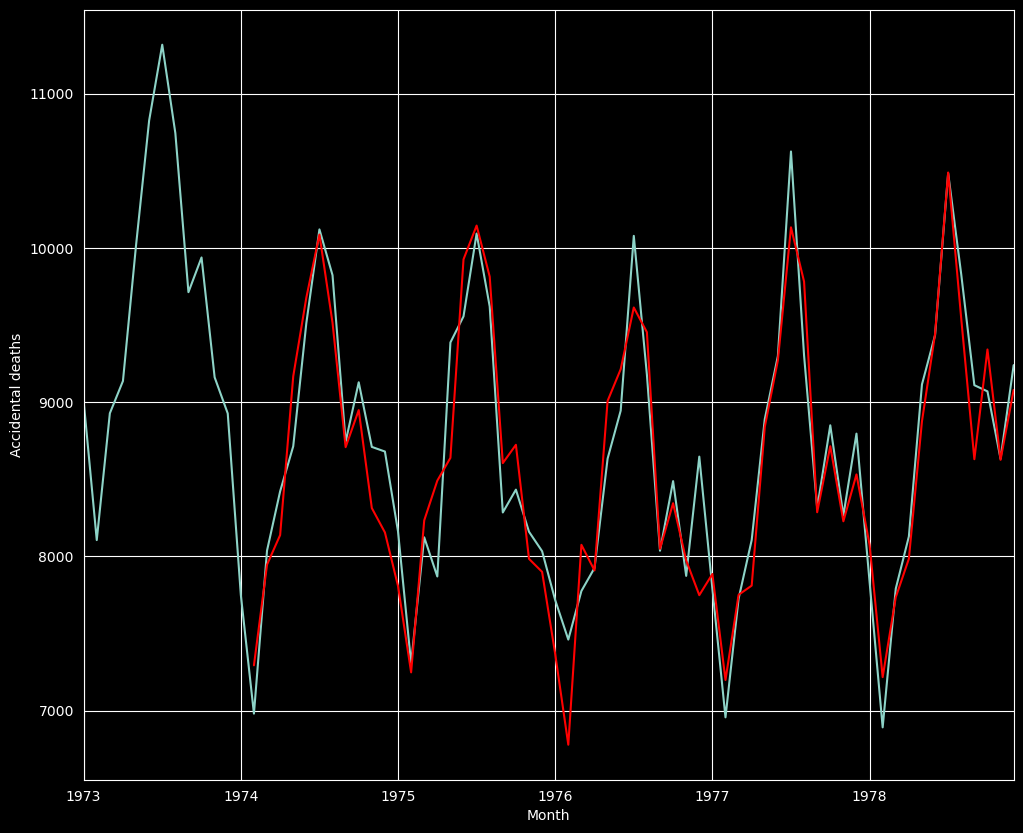

In [49]:
df['Model'] = best_model.fittedvalues
df['num_deaths'].plot()
df['Model'][13:].plot(color='r')
plt.ylabel('Accidental deaths');

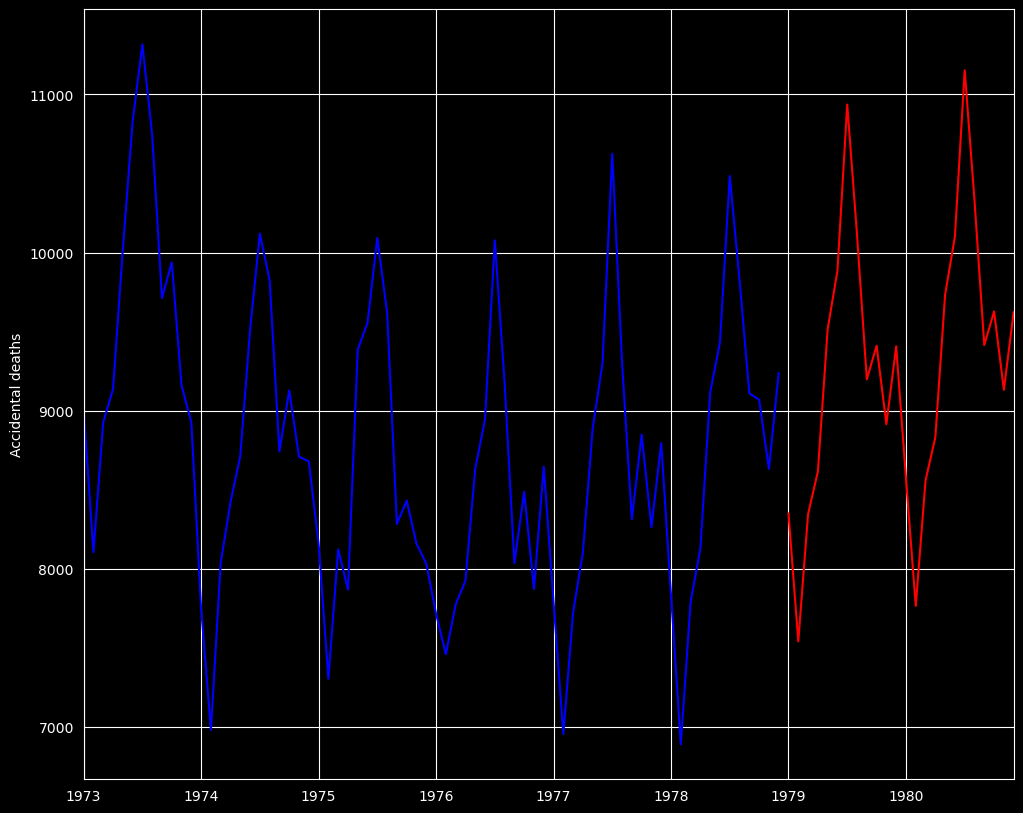

In [50]:
from dateutil.relativedelta import relativedelta

df_new = df[['num_deaths']]
date_list = [
    pd.Timestamp("1979-01-01") + relativedelta(months=x)
    for x in range(0, 24)
]

future = pd.DataFrame(index=date_list, columns=df_new.columns)
df_new = pd.concat([df_new, future])
df_new['forecast'] = best_model.predict(start=72, end=100)

df_new['num_deaths'].plot(color='b')
df_new['forecast'].plot(color='r')
plt.ylabel('Accidental deaths');